# **An Interpretable Machine Learning Framework for Predicting and Managing Healthcare Worker Attrition**

# Import libraries

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from imblearn.over_sampling import SMOTENC
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

!pip install pytorch_tabnet
!pip install catboost

In [2]:
import sklearn
print(sklearn.__version__)

1.6.1


# Load Dataset

In [3]:
df = pd.read_csv("/content/watson_healthcare_modified.csv")
df.head(3)

,EmployeeID,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1313919,41,No,Travel_Rarely,1102,Cardiology,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,1200302,49,No,Travel_Frequently,279,Maternity,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,1060315,37,Yes,Travel_Rarely,1373,Maternity,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0


In [4]:
df['Attrition'].value_counts()

,count
Attrition,
No,1477
Yes,199


In [5]:
df.shape

(1676, 35)

# Exploratory Data Analysis

In [6]:
attrition_yes_percentage = (df['Attrition'].value_counts(normalize=True) * 100)['Yes']
attrition_no_percentage = 100 - attrition_yes_percentage
print(f"The percentage of Attrition values that are 'Yes' is: {attrition_yes_percentage:.2f}% and 'No' is: {attrition_no_percentage:.2f}%")

The percentage of Attrition values that are 'Yes' is: 11.87% and 'No' is: 88.13%


In [7]:
print(df.isnull().any())

EmployeeID                  False
Age                         False
Attrition                   False
BusinessTravel              False
DailyRate                   False
Department                  False
DistanceFromHome            False
Education                   False
EducationField              False
EmployeeCount               False
EnvironmentSatisfaction     False
Gender                      False
HourlyRate                  False
JobInvolvement              False
JobLevel                    False
JobRole                     False
JobSatisfaction             False
MaritalStatus               False
MonthlyIncome               False
MonthlyRate                 False
NumCompaniesWorked          False
Over18                      False
OverTime                    False
PercentSalaryHike           False
PerformanceRating           False
RelationshipSatisfaction    False
StandardHours               False
Shift                       False
TotalWorkingYears           False
TrainingTimesL

In [8]:
# removing columns with static value (similar value for all) and primary key value
cols_to_remove = [col for col in df.columns if df[col].nunique() == 1]
cols_to_remove.append('EmployeeID')
print("Columns to remove due to having static value:")
print(cols_to_remove)
df = df.drop(columns=cols_to_remove)

Columns to remove due to having static value:
['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeID']


In [9]:
df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,No,Travel_Rarely,1102,Cardiology,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Maternity,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Maternity,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0


# Visualization

## Bar-diagram

In [ ]:
for column in df.columns:
  if column != 'Attrition':  # Exclude the target attribute
    count = df.groupby([column, 'Attrition']).size().reset_index(name='Count')
    fig = px.bar(count, x=column, y='Count', color='Attrition', title=column, width=600, height=400,
                 color_discrete_map={'No': 'skyblue', 'Yes': 'Purple'})
    fig.show()

These columns need to be analysed from Bar-diagram


* JobLevel
* JobRole
* MaritalStatus
* NumCompaniesWorked
* OverTime
* Shift
* TotalWorkingYears
* YearsAtCompany
* YearsInCurrentRole

## Box-plots

In [ ]:
for column in df.columns:
  if column != 'Attrition' and pd.api.types.is_numeric_dtype(df[column]):
    fig = px.box(df, x='Attrition', y=column, color='Attrition', height=300, width=400,
                 color_discrete_map={'0': 'skyblue', '1': 'Purple'})
    fig.show()

# Encoding

In [ ]:
cols_to_encode = [col for col in df.columns if df[col].dtype == 'object']
print("Columns that may need encoding:")
print(cols_to_encode)

Columns that may need encoding:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


## Manual

In [ ]:
# Map Attrition to 1 and 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Map BusinessTravel to ordinal values
business_travel_mapping = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df['BusinessTravel'] = df['BusinessTravel'].map(business_travel_mapping)

# Map Gender to 1 and 0
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Map OverTime to 1 and 0
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

## One-hot

In [ ]:
boolean_cols = []

for column in df.columns:
    if all(isinstance(x, bool) for x in df[column].unique()):
        boolean_cols.append(column)

print("Columns with 'True', 'False' values:")
print(boolean_cols)

Columns with 'True', 'False' values:
[]


In [ ]:
df_2 = df[cols_to_encode]
df_2

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,0,1,Cardiology,Life Sciences,0,Nurse,Single,1
1,0,2,Maternity,Life Sciences,1,Other,Married,0
2,1,1,Maternity,Other,1,Nurse,Single,1
3,0,2,Maternity,Life Sciences,0,Other,Married,1
4,0,1,Maternity,Medical,1,Nurse,Married,0
...,...,...,...,...,...,...,...,...
1671,1,1,Neurology,Technical Degree,1,Nurse,Single,1
1672,0,1,Cardiology,Marketing,0,Nurse,Married,1
1673,0,1,Maternity,Life Sciences,0,Other,Single,0
1674,0,1,Neurology,Life Sciences,0,Therapist,Married,0


In [ ]:
# Perform one-hot encoding for the remaining categorical columns
df = pd.get_dummies(df, columns=['Department', 'EducationField', 'JobRole', 'MaritalStatus'], drop_first=True).replace({True: 1, False: 0})

/tmp/ipykernel_15459/2349629651.py:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [ ]:
df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Administrative,JobRole_Nurse,JobRole_Other,JobRole_Therapist,MaritalStatus_Married,MaritalStatus_Single
0,41,0,1,1102,1,2,2,0,94,3,...,0,0,0,0,0,1,0,0,0,1
1,49,0,2,279,8,1,3,1,61,2,...,0,0,0,0,0,0,1,0,1,0
2,37,1,1,1373,2,2,4,1,92,2,...,0,0,1,0,0,1,0,0,0,1


In [ ]:
for column in df.columns:
  df[column] = df[column].astype(float)
df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Administrative,JobRole_Nurse,JobRole_Other,JobRole_Therapist,MaritalStatus_Married,MaritalStatus_Single
0,41.0,0.0,1.0,1102.0,1.0,2.0,2.0,0.0,94.0,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49.0,0.0,2.0,279.0,8.0,1.0,3.0,1.0,61.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,37.0,1.0,1.0,1373.0,2.0,2.0,4.0,1.0,92.0,2.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
# saving the current df
df.to_csv('df_encoded.csv', index=False)
# from google.colab import files
# files.download('df_encoded.csv')

# Feature Extraction

## Pearson Correlation

In [ ]:
def calculate_correlation_matrix(df):
  # Calculate the correlation matrix
  corr_matrix = df.corr()

  # Generate a mask for the upper triangle
  mask = corr_matrix.mask(np.triu(np.ones_like(corr_matrix), k=1).astype(bool))

  # Plot the heatmap
  plt.figure(figsize=(35, 35))
  sns.heatmap(mask, annot=True, cmap='coolwarm', fmt=".2f")
  plt.title('Correlation Matrix')
  plt.show()

calculate_correlation_matrix(df)

## Mutual Information

In [ ]:
def calculate_mutual_information(df):
  # Separate features and target
  X = df.drop('Attrition', axis=1)
  y = df['Attrition']

  # Calculate mutual information
  mutual_info = mutual_info_classif(X, y, random_state=111)

  # Create a DataFrame to visualize the results
  mutual_info_df = pd.DataFrame({'Feature': X.columns, 'Mutual Information': mutual_info})
  mutual_info_df = mutual_info_df.sort_values(by='Mutual Information', ascending=False)

  # Plot the mutual information scores
  plt.figure(figsize=(10, 8))
  sns.barplot(x='Mutual Information', y='Feature', data=mutual_info_df)
  plt.title('Mutual Information with Attrition')
  plt.show()
  return mutual_info_df

mutual_info_df = calculate_mutual_information(df)
zero_mi_features = mutual_info_df[mutual_info_df['Mutual Information'] == 0]['Feature'].tolist()
print("Columns with zero mutual information:")
print(zero_mi_features)

## Chi-squared Test

In [ ]:
def calculate_chi_squared(df):
  chi_squared_df = df

  # Separate features and target
  X = chi_squared_df.drop('Attrition', axis=1)
  y = chi_squared_df['Attrition']

  # Apply Chi-Square test
  chi2_selector = SelectKBest(chi2, k='all')  # Select all features based on Chi-Square scores
  X_kbest = chi2_selector.fit_transform(X, y)

  # Display Chi-Square scores for each feature
  chi2_scores = chi2_selector.scores_
  p_values = chi2_selector.pvalues_

  # Create a DataFrame to show the feature names, Chi-Square scores, and p-values
  results = pd.DataFrame({
      'Feature': X.columns,
      'Chi-Square Score': chi2_scores,
      'p-value': p_values
  })

  # Sort the results DataFrame by Chi-Square Score
  results_sorted = results.sort_values(by='Chi-Square Score', ascending=False)

  # Plot the Chi-Square scores
  plt.figure(figsize=(8, 10))
  #plt.bar(results_sorted['Feature'], results_sorted['Chi-Square Score'])
  sns.barplot(x=results_sorted['Chi-Square Score'], y=results_sorted['Feature'])
  plt.xlabel('Chi-Squared Score (log-scaled)')
  plt.ylabel('Features')
  plt.title('Chi-Squared Scores for Features')
  plt.xscale('log')  # Use logarithmic scale for better visualization of small values
  plt.show()

  #more_significant_features = results[results['p-value'] < 0.05]
  less_significant_features = results[results['p-value'] >= 0.5]

  print(less_significant_features)
  return less_significant_features

less_significant_features_chi2 = calculate_chi_squared(df)

## Recursive Feature Elimination

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

def do_rfecv(df):
  # Separate features and target
  X = df.drop('Attrition', axis=1)
  y = df['Attrition']

  # Create the RFE object with cross-validation
  rfecv = RFECV(estimator=RandomForestClassifier(random_state=42), step=1, cv=StratifiedKFold(5), scoring='accuracy')

  # Fit RFECV to the data
  rfecv.fit(X, y)

  # Print the optimal number of features
  print("Optimal number of features : %d" % rfecv.n_features_)

  # Print the selected features
  selected_features = X.columns[rfecv.support_]
  print("Selected features:", selected_features)

  # Plot number of features VS. cross-validation scores
  plt.figure()
  plt.xlabel("Number of features selected")
  plt.ylabel("Cross validation score (nb of correct classifications)")
  #plt.plot(range(1, len(rfecv.grid_scores) + 1), rfecv.grid_scores_)
  plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], color='#303F9F', linewidth=3)
  plt.show()

  return selected_features

selected_features = do_rfecv(df)

Monthly Income and JobLevel have high correlation -> need to remove one of them

In [ ]:
features_from_rfecv = ['Age', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'RelationshipSatisfaction', 'Shift', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'Department_Maternity', 'Department_Neurology',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'JobRole_Nurse', 'JobRole_Other', 'MaritalStatus_Married',
       'MaritalStatus_Single']

In [ ]:
features_in_df = set(df.columns)
features_not_in_rfecv = features_in_df - set(features_from_rfecv)
features_not_in_rfecv

In [ ]:
#features_to_remove = ['Education', 'PercentSalaryHike', 'PerformanceRating', 'EducationField_Life Sciences', 'EducationField_Medical', 'EducationField_Technical Degree', 'Department_Maternity', 'Gender', 'RelationshipSatisfaction', 'PercentSalaryHike']

## Eliminating features

In [ ]:
features_to_remove = ['PerformanceRating', 'EducationField_Medical', 'EducationField_Technical Degree', 'Department_Maternity', 'Gender', 'RelationshipSatisfaction']

In [ ]:
df = df.drop(columns=list(features_to_remove))

In [ ]:
#its box plot says it has more anomalous data, so dropping 'MonthlyIncome'
df = df.drop(columns=['MonthlyIncome'])

In [ ]:
# saving the current df
df.to_csv('df_encoded_dropped.csv', index=False)
# from google.colab import files
# files.download('df_encoded.csv')

# Handling Outliers

## Box-cox transformation

In [ ]:
df = pd.read_csv('/content/df_encoded_dropped.csv')
numerical_features = [col for col in df.columns if df[col].nunique() > 10]
df_num_fet = df[numerical_features]

In [ ]:
df.shape

In [ ]:
from scipy import stats

def apply_boxcox(data, plot=True):
    """
    Apply Box-Cox transformation to data.
    Handles negative values by shifting all data to positive.

    Parameters:
    -----------
    data : array-like
        The data to transform
    plot : bool, default=True
        Whether to plot before and after transformation

    Returns:
    --------
    tuple
        (transformed_data, lambda_value)
    """
    # Box-Cox requires positive values
    min_val = np.min(data)
    if min_val <= 0:
        # Shift data to make all values positive
        shifted_data = data - min_val + 1
    else:
        shifted_data = data

    # Apply Box-Cox transformation
    transformed_data, lambda_value = stats.boxcox(shifted_data)

    if plot:
        # Create plot to show before and after
        fig, ax = plt.subplots(1, 2, figsize=(6, 2))

        # Original data
        ax[0].hist(data, bins=30, alpha=0.7)
        ax[0].set_title('Original Data')
        ax[0].set_xlabel('Value')
        ax[0].set_ylabel('Frequency')

        # Transformed data
        ax[1].hist(transformed_data, bins=30, alpha=0.7)
        ax[1].set_title(f'After Box-Cox (λ = {lambda_value:.4f})')
        ax[1].set_xlabel('Transformed Value')
        ax[1].set_ylabel('Frequency')

        plt.tight_layout()
        plt.show()

    return transformed_data, lambda_value

for col in numerical_features:
  # Apply Box-Cox transformation
  transformed_data, lambda_value = apply_boxcox(df_num_fet[col])
  # Add transformed data to DataFrame
  df_num_fet[col] = transformed_data

In [ ]:
#Box-transformation
import scipy
for col in df.columns:
  if col in numerical_features:
    print(f"=== {col} ===")
    df.loc[df[col] == 0, col] = 0.1

    #box_cox_to_original[col] = df[col].copy()

    sns.boxplot(df[col])
    plt.title("Box Plot before outlier removing")
    plt.show()
    df[col],fitted_lambda= scipy.stats.boxcox(df[col] ,lmbda=None)
    sns.boxplot(df[col])
    plt.title("Box Plot after outlier removing")
    plt.show()

In [ ]:
# Check if df_old and df are equal
if df_num_fet.equals(df):
  print("df_num_fet and df are equal.")
else:
  print("df_num_fet and df are not equal.")


In [ ]:
#def handle_outliers_iqr(df, column):
  #"""Handles outliers using the Interquartile Range (IQR) method.

  #Args:
  #  df: The DataFrame containing the data.
  #  column: The name of the column to handle outliers for.

  #Returns:
  #  The DataFrame with outliers replaced by the nearest bound.
  #"""
  #print(f"=== {column} ===")
  #Q1 = df[column].quantile(0.25)
  #Q3 = df[column].quantile(0.75)
  #IQR = Q3 - Q1
  #lower_bound = Q1 - 1.5 * IQR
  #upper_bound = Q3 + 1.5 * IQR

  #print(f"lower-outliers: {np.where(df[column] < lower_bound)}")
  #print(f"lower-bound: {lower_bound}")
  #print(f"higher-outliers: {np.where(df[column] > upper_bound)[0]}")
  #print(f"upper-bound: {upper_bound}")

  # Replace outliers with the nearest bound
  #df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
  #df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
  #return df

#df_dummy = df
# Apply outlier handling to numerical columns
#for column in numerical_features:
  #df = handle_outliers_iqr(df, column)


In [ ]:
"""from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd
train = df
def Iso_outliers(df):
    print(f"=== {df.name} ===")
    iso = IsolationForest(random_state = 1, contamination= 'auto')
    preds = iso.fit_predict(df.values.reshape(-1,1))
    data = pd.DataFrame()
    data['cluster'] = preds
    print(data['cluster'].value_counts().sort_values(ascending=False))

df_dummy = df.copy()
# Apply outlier handling to numerical columns
for column in df_dummy.columns:
  if pd.api.types.is_numeric_dtype(df_dummy[column]):
    Iso_outliers(df_dummy[column])"""

In [ ]:
for column in df.columns:
  if column in df_num_fet.columns:
    df[column] = df_num_fet[column]

In [ ]:
# saving the current df
df.to_csv('df_encoded_dropped_outlhandled_new.csv', index=False)
# from google.colab import files
# files.download('df_encoded_dropped_outlhandled_new.csv')

# Upsampling and Normalization

In [ ]:
df = pd.read_csv('/content/df_encoded_dropped_outlhandled_new.csv')

In [ ]:
df.shape

## Upsampling with SMOTE-NC

In [ ]:
def Apply_SMOTE_NC(X, y):
  # Identify the indices of categorical features
  categorical_features = [col for col in X.columns if X[col].nunique() < 5]

  # Apply SMOTENC to the training data
  smote_nc = SMOTENC(categorical_features=categorical_features, random_state=42)
  X_res_smote_nc, y_res_smote_nc = smote_nc.fit_resample(X, y)

  # Check the class distribution after SMOTENC
  print(f"Resampled class distribution (SMOTENC): {Counter(y_res_smote_nc)}")
  #df = pd.concat([X_res_smote_nc, y_res_smote_nc], axis=1)
  return X_res_smote_nc, y_res_smote_nc

## Normalize with Z-score

In [ ]:
def Normalize_data(df):
  columns_to_normalize = [col for col in df.columns if df[col].nunique() > 10]
  # Standardization (Z-score normalization)
  scaler = StandardScaler()
  df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
  return df

# Training

In [ ]:
df = pd.read_csv('/content/df_encoded_dropped_outlhandled_new.csv')

In [ ]:
from sklearn.model_selection import StratifiedKFold

def perform_kfold_stratified_validation(df, target_column, n_splits=5):
  X = df.drop(target_column, axis=1)
  y = df[target_column]

  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

  print(f"Performing {n_splits}-fold stratified cross-validation...")
  for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
    print(f"Train target distribution:\n{y_train.value_counts(normalize=True)}")
    print(f"Train target counts:\n{y_train.value_counts()}")
    print(f"Test target distribution:\n{y_test.value_counts(normalize=True)}")
    print(f"Test target counts:\n{y_test.value_counts()}")

  return X, y, skf

X_strat, y_strat, skf_folds = perform_kfold_stratified_validation(df.copy(), 'Attrition')


### K-Fold Cross-Validation for Model Training and Evaluation

In [46]:
from sklearn.preprocessing import StandardScaler
from collections import Counter
from sklearn.ensemble import StackingClassifier
from catboost import CatBoostClassifier

def train_and_evaluate_single_model_per_fold(model_instance, X_train_fold, y_train_fold, X_test_fold, y_test_fold, rand_num):
  # Ensure random states are set if applicable
  if hasattr(model_instance, 'random_state'):
    model_instance.random_state = rand_num
  if isinstance(model_instance, CatBoostClassifier):
      model_instance.set_params(random_state=rand_num, verbose=False)

  # 1. Apply SMOTE-NC to the training data within the fold
  # The categorical features are identified within Apply_SMOTE_NC function.
  X_train_resampled, y_train_resampled = Apply_SMOTE_NC(X_train_fold.copy(), y_train_fold.copy())

  # 2. Normalize data: Fit scaler on resampled training data and transform it, then transform test data
  scaler = StandardScaler()
  # Identify numerical columns to normalize (features with more than 10 unique values)
  # This assumes 'df' is available in the global scope or passed around, but for the scope of this function,
  # we need to ensure the columns are correctly identified from X_train_resampled
  columns_to_normalize = [col for col in X_train_resampled.columns if X_train_resampled[col].nunique() > 10]

  X_train_resampled_scaled = X_train_resampled.copy()
  X_test_fold_scaled = X_test_fold.copy()

  X_train_resampled_scaled[columns_to_normalize] = scaler.fit_transform(X_train_resampled[columns_to_normalize])
  X_test_fold_scaled[columns_to_normalize] = scaler.transform(X_test_fold[columns_to_normalize])

  # Train the model
  model_instance.fit(X_train_resampled_scaled, y_train_resampled)

  # Predict and evaluate
  y_pred = model_instance.predict(X_test_fold_scaled)

  accuracy = accuracy_score(y_test_fold, y_pred)
  precision = precision_score(y_test_fold, y_pred, average='macro')
  recall = recall_score(y_test_fold, y_pred, average='macro')
  f1 = f1_score(y_test_fold, y_pred, average='macro')

  return accuracy, precision, recall, f1, y_pred

def perform_kfold_stratified_validation_with_models(df, target_column, n_splits=5):
  X = df.drop(target_column, axis=1)
  y = df[target_column]

  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

  all_fold_results = []

  print(f"Performing {n_splits}-fold stratified cross-validation for multiple models...")

  count = 0
  for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    print(f"Train samples: {len(X_train_fold)}, Test samples: {len(X_test_fold)}")
    print(f"Train target distribution:\n{y_train_fold.value_counts(normalize=True)}")
    print(f"Test target distribution:\n{y_test_fold.value_counts(normalize=True)}")


    # Define models to train for this fold (fresh instances)
    rand_num_fold = 42 # Use a fixed seed for each fold
    models_to_evaluate = {
        'Logistic Regression': LogisticRegression(random_state=rand_num_fold),
        'SVM': SVC(probability=True, random_state=rand_num_fold),
        'KNN': KNeighborsClassifier(),
        'Decision Tree': DecisionTreeClassifier(random_state=rand_num_fold),
        'Random Forest': RandomForestClassifier(random_state=rand_num_fold),
        'Gradient Boosting': GradientBoostingClassifier(random_state=rand_num_fold),
        'Ada Boost': AdaBoostClassifier(random_state=rand_num_fold),
        'XGBoost': XGBClassifier(random_state=rand_num_fold),
        'LightGBM': LGBMClassifier(random_state=rand_num_fold),
        'CatBoost': CatBoostClassifier(random_state=rand_num_fold, verbose=False),
        'Stacking': StackingClassifier(
            estimators=[
                ('rf', RandomForestClassifier(n_estimators=100, random_state=rand_num_fold)),
                ('cat', CatBoostClassifier(verbose=0, random_state=rand_num_fold)),
                ('svc', SVC(probability=True, random_state=rand_num_fold))
            ],
            final_estimator=LogisticRegression(random_state=rand_num_fold)
        )
    }

    for name, model_instance in models_to_evaluate.items():
      print(f"Training {name} for Fold {fold + 1}...")
      print(f"Train fold count: {X_train_fold.shape[0]}")
      print(f"Test fold count: {X_test_fold.shape[0]}")
      print(f"Attrition distribution in train: {y.value_counts(normalize=True)}")
      print(f"Attrition distribution in test: {y_test_fold.value_counts(normalize=True)}")
      accuracy, precision, recall, f1, y_pred = train_and_evaluate_single_model_per_fold(
          model_instance, X_train_fold, y_train_fold, X_test_fold, y_test_fold, rand_num_fold
      )

      if count == 0:
        cm = confusion_matrix(y_test_fold, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_instance.classes_)
        disp.plot()
        plt.show()
      all_fold_results.append([name, fold + 1, accuracy, precision, recall, f1])

    count += 1
  return pd.DataFrame(all_fold_results, columns=['Model', 'Fold', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

def perform_kfold_stratified_validation_with_mlp(df, target_column, n_splits=5):
  X = df.drop(target_column, axis=1)
  y = df[target_column]
  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
  all_fold_results_mlp = []
  print(f"Performing {n_splits}-fold stratified cross-validation for MLP...")

  count = 0
  for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    print(f"\n--- Fold {fold + 1}/{n_splits} (MLP) ---")

    # Apply SMOTE-NC to training data
    X_train_resampled, y_train_resampled = Apply_SMOTE_NC(X_train_fold.copy(), y_train_fold.copy())

    # Normalize data
    scaler = StandardScaler()
    columns_to_normalize = [col for col in X_train_resampled.columns if X_train_resampled[col].nunique() > 10]
    X_train_resampled_scaled = X_train_resampled.copy()
    X_test_fold_scaled = X_test_fold.copy()
    X_train_resampled_scaled[columns_to_normalize] = scaler.fit_transform(X_train_resampled[columns_to_normalize])
    X_test_fold_scaled[columns_to_normalize] = scaler.transform(X_test_fold[columns_to_normalize])

    # Prepare data for PyTorch
    X_train_tensor = torch.tensor(X_train_resampled_scaled.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_resampled.values, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_fold_scaled.values, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_fold.values, dtype=torch.float32)

    train_dataset = TabularDataset(X_train_resampled_scaled, y_train_resampled)
    test_dataset = TabularDataset(X_test_fold_scaled, y_test_fold)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    input_size = X_train_resampled_scaled.shape[1]
    hidden_size1 = 20
    hidden_size2 = 20
    output_size = 1
    model = MLP(input_size, hidden_size1, hidden_size2, output_size)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    num_epochs = 30 # Reduced epochs for faster execution in Colab

    for epoch in range(num_epochs):
      model.train()
      for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y.unsqueeze(1))
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
      y_pred_probs = []
      for batch_X, _ in test_loader:
        outputs = model(batch_X)
        y_pred_probs.extend(outputs.tolist())

    y_pred = [1 if prob[0] >= 0.5 else 0 for prob in y_pred_probs]

    accuracy = accuracy_score(y_test_fold, y_pred)
    precision = precision_score(y_test_fold, y_pred, average='macro')
    recall = recall_score(y_test_fold, y_pred, average='macro')
    f1 = f1_score(y_test_fold, y_pred, average='macro')
    all_fold_results_mlp.append(['MLP', fold + 1, accuracy, precision, recall, f1])
    if count == 0:
      cm = confusion_matrix(y_test_fold, y_pred)
      disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test_fold))
      disp.plot()
      plt.show()
    count += 1

  return pd.DataFrame(all_fold_results_mlp, columns=['Model', 'Fold', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

def perform_kfold_stratified_validation_with_cnn(df, target_column, n_splits=5):
  X = df.drop(target_column, axis=1)
  y = df[target_column]
  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
  all_fold_results_cnn = []
  print(f"Performing {n_splits}-fold stratified cross-validation for CNN...")

  count = 0
  for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    print(f"\n--- Fold {fold + 1}/{n_splits} (CNN) ---")

    # Apply SMOTE-NC to training data
    X_train_resampled, y_train_resampled = Apply_SMOTE_NC(X_train_fold.copy(), y_train_fold.copy())

    # Normalize data
    scaler = StandardScaler()
    columns_to_normalize = [col for col in X_train_resampled.columns if X_train_resampled[col].nunique() > 10]
    X_train_resampled_scaled = X_train_resampled.copy()
    X_test_fold_scaled = X_test_fold.copy()
    X_train_resampled_scaled[columns_to_normalize] = scaler.fit_transform(X_train_resampled[columns_to_normalize])
    X_test_fold_scaled[columns_to_normalize] = scaler.transform(X_test_fold[columns_to_normalize])

    # Prepare data for PyTorch
    train_dataset = TabularDataset(X_train_resampled_scaled, y_train_resampled)
    test_dataset = TabularDataset(X_test_fold_scaled, y_test_fold)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    input_size = X_train_resampled_scaled.shape[1]
    num_filters = 32
    kernel_size = 4
    output_size = 1
    model = TabularCNN(input_size, num_filters, kernel_size, output_size)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    num_epochs = 30 # Reduced epochs for faster execution in Colab
    for epoch in range(num_epochs):
      model.train()
      for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y.unsqueeze(1))
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
      y_pred_probs = []
      for batch_X, _ in test_loader:
        outputs = model(batch_X)
        y_pred_probs.extend(outputs.tolist())

    y_pred = [1 if prob[0] >= 0.5 else 0 for prob in y_pred_probs]

    accuracy = accuracy_score(y_test_fold, y_pred)
    precision = precision_score(y_test_fold, y_pred, average='macro')
    recall = recall_score(y_test_fold, y_pred, average='macro')
    f1 = f1_score(y_test_fold, y_pred, average='macro')
    all_fold_results_cnn.append(['CNN', fold + 1, accuracy, precision, recall, f1])

    if count == 0:
        cm = confusion_matrix(y_test_fold, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test_fold))
        disp.plot()
        plt.show()
    count += 1
  return pd.DataFrame(all_fold_results_cnn, columns=['Model', 'Fold', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

def perform_kfold_stratified_validation_with_tabnet(df, target_column, n_splits=5):
  X = df.drop(target_column, axis=1)
  y = df[target_column]
  skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
  all_fold_results_tabnet = []
  print(f"Performing {n_splits}-fold stratified cross-validation for TabNet...")

  count = 0
  for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    print(f"\n--- Fold {fold + 1}/{n_splits} (TabNet) ---")

    # Apply SMOTE-NC to training data
    X_train_resampled, y_train_resampled = Apply_SMOTE_NC(X_train_fold.copy(), y_train_fold.copy())

    # Normalize data
    scaler = StandardScaler()
    columns_to_normalize = [col for col in X_train_resampled.columns if X_train_resampled[col].nunique() > 10]
    X_train_resampled_scaled = X_train_resampled.copy()
    X_test_fold_scaled = X_test_fold.copy()
    X_train_resampled_scaled[columns_to_normalize] = scaler.fit_transform(X_train_resampled[columns_to_normalize])
    X_test_fold_scaled[columns_to_normalize] = scaler.transform(X_test_fold[columns_to_normalize])

    # Train TabNet model
    model = TabNetClassifier(verbose=0)
    model.fit(
        X_train_resampled_scaled.values, y_train_resampled.values,
        eval_set=[(X_test_fold_scaled.values, y_test_fold.values)],
        patience=10, max_epochs=30
    )
    y_pred = model.predict(X_test_fold_scaled.values)

    accuracy = accuracy_score(y_test_fold, y_pred)
    precision = precision_score(y_test_fold, y_pred, average='macro')
    recall = recall_score(y_test_fold, y_pred, average='macro')
    f1 = f1_score(y_test_fold, y_pred, average='macro')
    all_fold_results_tabnet.append(['TabNet', fold + 1, accuracy, precision, recall, f1])
    if count == 0:
      cm = confusion_matrix(y_test_fold, y_pred)
      disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
      disp.plot()
      plt.show()
    count += 1

  return pd.DataFrame(all_fold_results_tabnet, columns=['Model', 'Fold', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

Performing 5-fold stratified cross-validation for multiple models...

--- Fold 1/5 ---
Train samples: 1340, Test samples: 336
Train target distribution:
Attrition
0.0    0.881343
1.0    0.118657
Name: proportion, dtype: float64
Test target distribution:
Attrition
0.0    0.880952
1.0    0.119048
Name: proportion, dtype: float64
Training Logistic Regression for Fold 1...
Train fold count: 1340
Test fold count: 336
Attrition distribution in train: Attrition
0.0    0.881265
1.0    0.118735
Name: proportion, dtype: float64
Attrition distribution in test: Attrition
0.0    0.880952
1.0    0.119048
Name: proportion, dtype: float64
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})


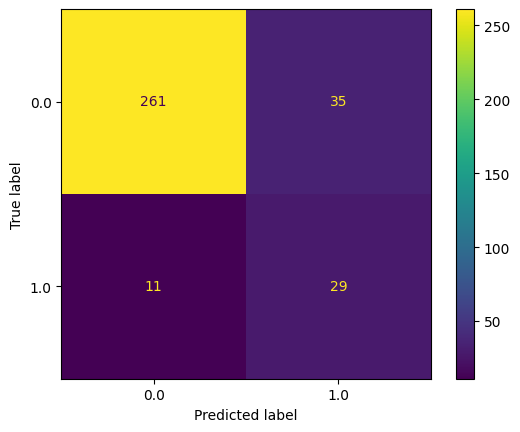

Training SVM for Fold 1...
Train fold count: 1340
Test fold count: 336
Attrition distribution in train: Attrition
0.0    0.881265
1.0    0.118735
Name: proportion, dtype: float64
Attrition distribution in test: Attrition
0.0    0.880952
1.0    0.119048
Name: proportion, dtype: float64
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})


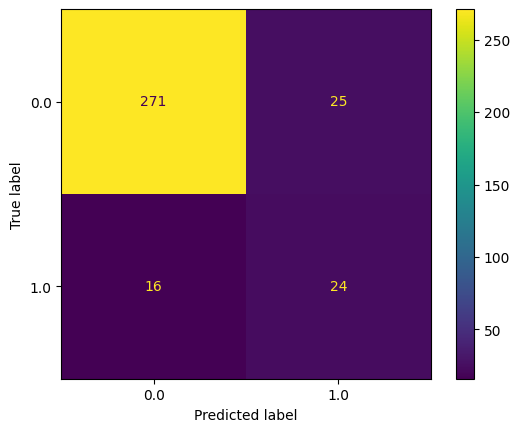

Training KNN for Fold 1...
Train fold count: 1340
Test fold count: 336
Attrition distribution in train: Attrition
0.0    0.881265
1.0    0.118735
Name: proportion, dtype: float64
Attrition distribution in test: Attrition
0.0    0.880952
1.0    0.119048
Name: proportion, dtype: float64
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})


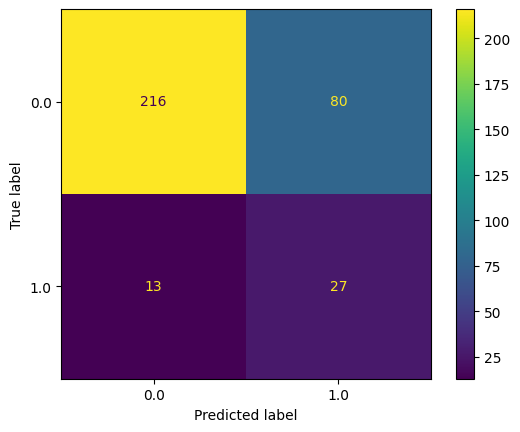

Training Decision Tree for Fold 1...
Train fold count: 1340
Test fold count: 336
Attrition distribution in train: Attrition
0.0    0.881265
1.0    0.118735
Name: proportion, dtype: float64
Attrition distribution in test: Attrition
0.0    0.880952
1.0    0.119048
Name: proportion, dtype: float64
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})


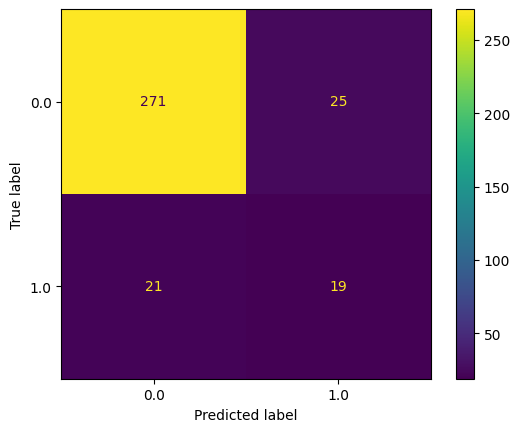

Training Random Forest for Fold 1...
Train fold count: 1340
Test fold count: 336
Attrition distribution in train: Attrition
0.0    0.881265
1.0    0.118735
Name: proportion, dtype: float64
Attrition distribution in test: Attrition
0.0    0.880952
1.0    0.119048
Name: proportion, dtype: float64
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})


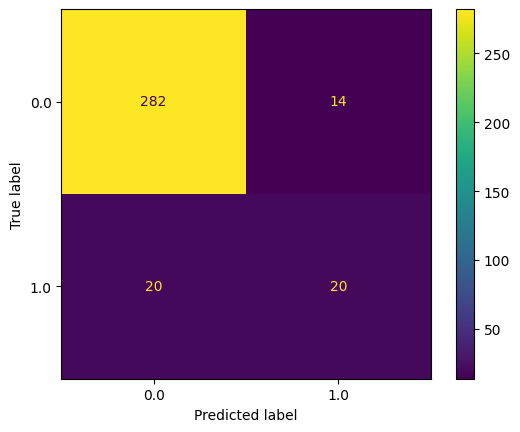

Training Gradient Boosting for Fold 1...
Train fold count: 1340
Test fold count: 336
Attrition distribution in train: Attrition
0.0    0.881265
1.0    0.118735
Name: proportion, dtype: float64
Attrition distribution in test: Attrition
0.0    0.880952
1.0    0.119048
Name: proportion, dtype: float64
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})


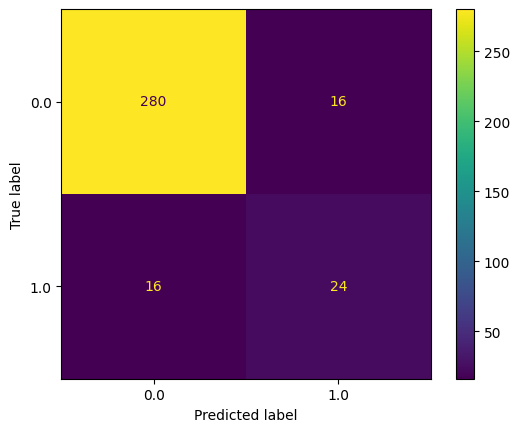

Training Ada Boost for Fold 1...
Train fold count: 1340
Test fold count: 336
Attrition distribution in train: Attrition
0.0    0.881265
1.0    0.118735
Name: proportion, dtype: float64
Attrition distribution in test: Attrition
0.0    0.880952
1.0    0.119048
Name: proportion, dtype: float64
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})


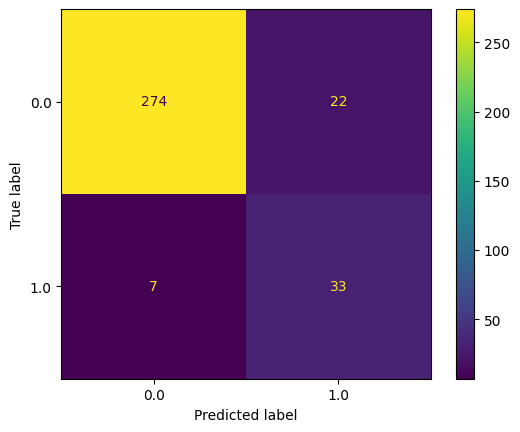

Training XGBoost for Fold 1...
Train fold count: 1340
Test fold count: 336
Attrition distribution in train: Attrition
0.0    0.881265
1.0    0.118735
Name: proportion, dtype: float64
Attrition distribution in test: Attrition
0.0    0.880952
1.0    0.119048
Name: proportion, dtype: float64
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})


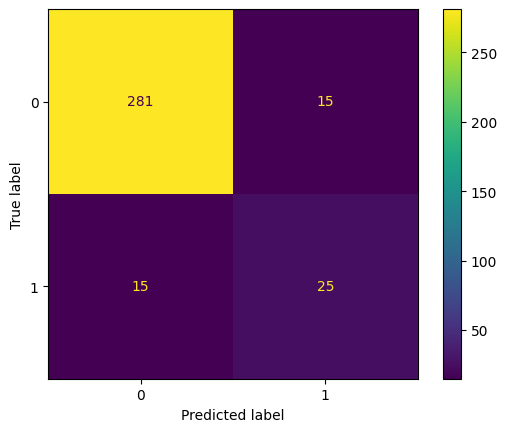

Training LightGBM for Fold 1...
Train fold count: 1340
Test fold count: 336
Attrition distribution in train: Attrition
0.0    0.881265
1.0    0.118735
Name: proportion, dtype: float64
Attrition distribution in test: Attrition
0.0    0.880952
1.0    0.119048
Name: proportion, dtype: float64
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1181, number of negative: 1181
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3840
[LightGBM] [Info] Number of data points in the train set: 2362, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


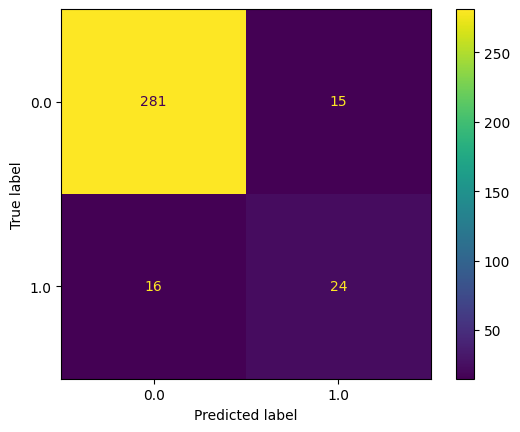

Training CatBoost for Fold 1...
Train fold count: 1340
Test fold count: 336
Attrition distribution in train: Attrition
0.0    0.881265
1.0    0.118735
Name: proportion, dtype: float64
Attrition distribution in test: Attrition
0.0    0.880952
1.0    0.119048
Name: proportion, dtype: float64
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})


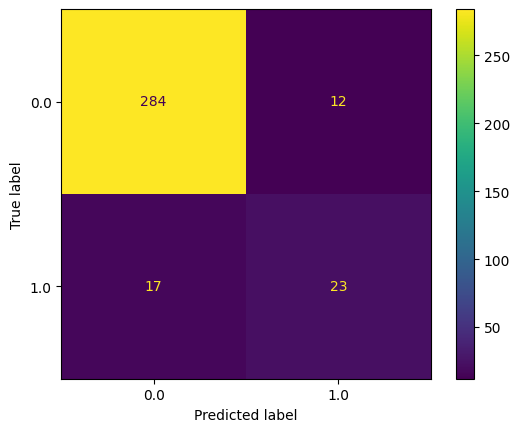

Training Stacking for Fold 1...
Train fold count: 1340
Test fold count: 336
Attrition distribution in train: Attrition
0.0    0.881265
1.0    0.118735
Name: proportion, dtype: float64
Attrition distribution in test: Attrition
0.0    0.880952
1.0    0.119048
Name: proportion, dtype: float64
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})


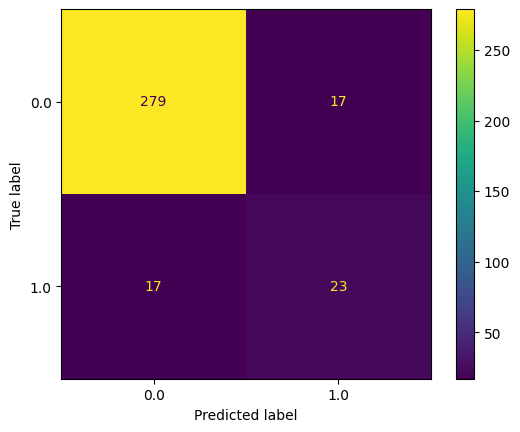


--- Fold 2/5 ---
Train samples: 1341, Test samples: 335
Train target distribution:
Attrition
0.0    0.880686
1.0    0.119314
Name: proportion, dtype: float64
Test target distribution:
Attrition
0.0    0.883582
1.0    0.116418
Name: proportion, dtype: float64
Training Logistic Regression for Fold 2...
Train fold count: 1341
Test fold count: 335
Attrition distribution in train: Attrition
0.0    0.881265
1.0    0.118735
Name: proportion, dtype: float64
Attrition distribution in test: Attrition
0.0    0.883582
1.0    0.116418
Name: proportion, dtype: float64
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})
Training SVM for Fold 2...
Train fold count: 1341
Test fold count: 335
Attrition distribution in train: Attrition
0.0    0.881265
1.0    0.118735
Name: proportion, dtype: float64
Attrition distribution in test: Attrition
0.0    0.883582
1.0    0.116418
Name: proportion, dtype: float64
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})
Training

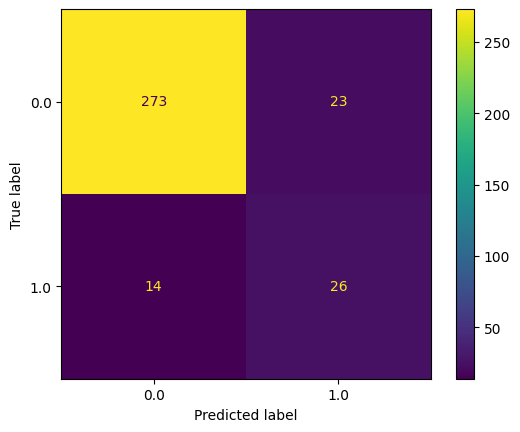


--- Fold 2/5 (MLP) ---
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})

--- Fold 3/5 (MLP) ---
Resampled class distribution (SMOTENC): Counter({0.0: 1182, 1.0: 1182})

--- Fold 4/5 (MLP) ---
Resampled class distribution (SMOTENC): Counter({0.0: 1182, 1.0: 1182})

--- Fold 5/5 (MLP) ---
Resampled class distribution (SMOTENC): Counter({0.0: 1182, 1.0: 1182})
Performing 5-fold stratified cross-validation for CNN...

--- Fold 1/5 (CNN) ---
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})


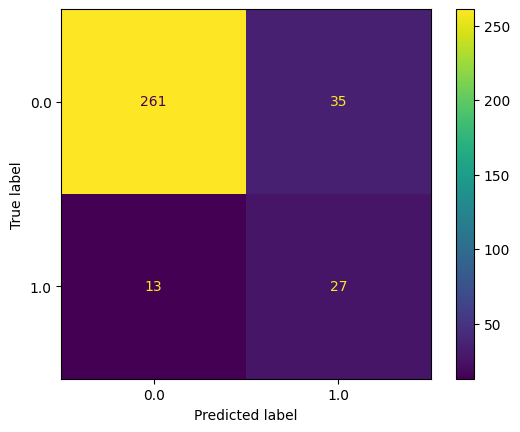


--- Fold 2/5 (CNN) ---
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})

--- Fold 3/5 (CNN) ---
Resampled class distribution (SMOTENC): Counter({0.0: 1182, 1.0: 1182})

--- Fold 4/5 (CNN) ---
Resampled class distribution (SMOTENC): Counter({0.0: 1182, 1.0: 1182})

--- Fold 5/5 (CNN) ---
Resampled class distribution (SMOTENC): Counter({0.0: 1182, 1.0: 1182})
Performing 5-fold stratified cross-validation for TabNet...

--- Fold 1/5 (TabNet) ---
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})

Early stopping occurred at epoch 27 with best_epoch = 17 and best_val_0_auc = 0.80591


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning:

Best weights from best epoch are automatically used!



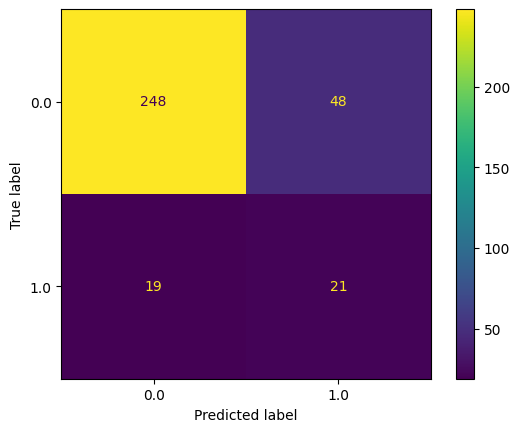


--- Fold 2/5 (TabNet) ---
Resampled class distribution (SMOTENC): Counter({0.0: 1181, 1.0: 1181})

Early stopping occurred at epoch 29 with best_epoch = 19 and best_val_0_auc = 0.82302

--- Fold 3/5 (TabNet) ---


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning:

Best weights from best epoch are automatically used!



Resampled class distribution (SMOTENC): Counter({0.0: 1182, 1.0: 1182})

Early stopping occurred at epoch 29 with best_epoch = 19 and best_val_0_auc = 0.82941

--- Fold 4/5 (TabNet) ---


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning:

Best weights from best epoch are automatically used!



Resampled class distribution (SMOTENC): Counter({0.0: 1182, 1.0: 1182})
Stop training because you reached max_epochs = 30 with best_epoch = 28 and best_val_0_auc = 0.87144

--- Fold 5/5 (TabNet) ---


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning:

Best weights from best epoch are automatically used!



Resampled class distribution (SMOTENC): Counter({0.0: 1182, 1.0: 1182})
Stop training because you reached max_epochs = 30 with best_epoch = 27 and best_val_0_auc = 0.76771

--- K-Fold Cross-Validation Results per Fold ---


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning:

Best weights from best epoch are automatically used!



,Model,Fold,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1,0.863095,0.706342,0.803378,0.738353
1,SVM,1,0.877976,0.717023,0.757770,0.734500
2,KNN,1,0.723214,0.597784,0.702365,0.595102
3,Decision Tree,1,0.863095,0.679950,0.695270,0.687075
4,Random Forest,1,0.898810,0.761005,0.726351,0.741842
...,...,...,...,...,...,...
0,TabNet,1,0.800595,0.616593,0.681419,0.633158
1,TabNet,2,0.847761,0.675972,0.758013,0.702709
2,TabNet,3,0.886567,0.733188,0.762712,0.746536
3,TabNet,4,0.832836,0.674873,0.786229,0.704026



--- Aggregated K-Fold Cross-Validation Results ---


,Model,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1
7,Logistic Regression,0.887246,0.017821,0.742979,0.028675,0.836087,0.030800,0.776476,0.029873
1,CNN,0.887249,0.020890,0.744383,0.033415,0.827238,0.049084,0.773046,0.031993
0,Ada Boost,0.902738,0.010536,0.767338,0.020377,0.823075,0.037593,0.789886,0.023332
8,MLP,0.884842,0.006255,0.736490,0.007897,0.813045,0.024063,0.764704,0.004054
10,SVM,0.899774,0.022108,0.760449,0.042859,0.806252,0.056693,0.779988,0.047943
11,Stacking,0.918269,0.013991,0.809344,0.035356,0.790423,0.033918,0.798911,0.032592
2,CatBoost,0.922440,0.010916,0.826658,0.031544,0.781983,0.024445,0.801644,0.025601
4,Gradient Boosting,0.909908,0.006056,0.784924,0.014798,0.781296,0.025979,0.782848,0.020030
13,XGBoost,0.918262,0.008002,0.814843,0.028830,0.777328,0.022999,0.793120,0.018037
6,LightGBM,0.917667,0.010403,0.812662,0.027579,0.770441,0.034527,0.788700,0.030238


In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu = nn.ReLU()
        self.batchNorm1 = nn.BatchNorm1d(hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.batchNorm2 = nn.BatchNorm1d(hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, hidden_size2)
        self.batchNorm3 = nn.BatchNorm1d(hidden_size2) # Corrected BatchNorm name
        self.fc4 = nn.Linear(hidden_size2, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.batchNorm1(x)

        x = self.fc2(x)
        x = self.relu(x)
        x = self.batchNorm2(x)

        x = self.fc4(x)
        x = self.sigmoid(x)
        return x

class TabularCNN(nn.Module):
    def __init__(self, input_size, num_filters, kernel_size, output_size):
        super(TabularCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, num_filters, kernel_size)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=2)
        self.flatten = nn.Flatten()
        # Calculate the size after conv and maxpool, before flattening
        # (input_size - kernel_size + 1) -> output of conv1
        # // 2 -> output of maxpool
        conv_output_size = (input_size - kernel_size + 1) // 2
        if conv_output_size <= 0:
          raise ValueError(f"Convolutional output size is non-positive. Input size: {input_size}, Kernel size: {kernel_size}. Consider reducing kernel_size or increasing input_size.")

        self.fc1 = nn.Linear(num_filters * conv_output_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension for Conv1d
        x = self.conv1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.sigmoid(x)
        return x

# Run the k-fold cross-validation for traditional ML models and Stacking
kfold_results_df = perform_kfold_stratified_validation_with_models(df.copy(), 'Attrition')

# Run the k-fold cross-validation for MLP
kfold_results_mlp_df = perform_kfold_stratified_validation_with_mlp(df.copy(), 'Attrition')

# Run the k-fold cross-validation for CNN
kfold_results_cnn_df = perform_kfold_stratified_validation_with_cnn(df.copy(), 'Attrition')

# Run the k-fold cross-validation for TabNet
kfold_results_tabnet_df = perform_kfold_stratified_validation_with_tabnet(df.copy(), 'Attrition')

# Combine all results
all_kfold_results_df = pd.concat([kfold_results_df, kfold_results_mlp_df, kfold_results_cnn_df, kfold_results_tabnet_df])

# Display raw results
print("\n--- K-Fold Cross-Validation Results per Fold ---")
display(all_kfold_results_df)

# Aggregate results (mean and std dev) across folds for each model
aggregated_results = all_kfold_results_df.groupby('Model').agg(
    mean_accuracy=('Accuracy', 'mean'),
    std_accuracy=('Accuracy', 'std'),
    mean_precision=('Precision', 'mean'),
    std_precision=('Precision', 'std'),
    mean_recall=('Recall', 'mean'),
    std_recall=('Recall', 'std'),
    mean_f1=('F1 Score', 'mean'),
    std_f1=('F1 Score', 'std')
).reset_index()

print("\n--- Aggregated K-Fold Cross-Validation Results ---")
display(aggregated_results.sort_values(by='mean_recall', ascending=False))

## Statistical Comparison using Wilcoxon Signed-Rank Test

To determine if there are statistically significant differences in performance between the models, we will use the Wilcoxon signed-rank test. This non-parametric test is suitable for comparing two related samples (e.g., the performance of two models across multiple cross-validation folds).

In [ ]:
all_kfold_results_df['Model'].unique()

In [ ]:
from scipy.stats import wilcoxon
import itertools

# Get the list of unique models
models = all_kfold_results_df['Model'].unique()

# Dictionary to store p-values for pairwise comparisons
wilcoxon_p_values = {}

print("--- Pairwise Wilcoxon Signed-Rank Test (Recall Score) ---")

# Perform pairwise Wilcoxon tests
for model1, model2 in itertools.combinations(models, 2):
    recall_scores_model1 = all_kfold_results_df[all_kfold_results_df['Model'] == model1]['Recall']
    recall_scores_model2 = all_kfold_results_df[all_kfold_results_df['Model'] == model2]['Recall']

    # Check if there's enough data and variance for the test
    # Convert Series to numpy arrays for element-wise comparison to avoid ValueError
    if len(recall_scores_model1) > 1 and len(recall_scores_model2) > 1 and not (recall_scores_model1.to_numpy() == recall_scores_model2.to_numpy()).all():
        stat, p_value = wilcoxon(recall_scores_model1, recall_scores_model2)
        wilcoxon_p_values[f'{model1} vs {model2}'] = p_value
        # print(f'{model1} vs {model2}: p-value = {p_value:.4f}')
    else:
        wilcoxon_p_values[f'{model1} vs {model2}'] = None
        print(f'{model1} vs {model2}: Not enough variance or data for Wilcoxon test (Recall scores are identical or only one data point).')

# Display results in a DataFrame for better readability
wilcoxon_results_df = pd.DataFrame(wilcoxon_p_values.items(), columns=['Comparison', 'P-value'])
wilcoxon_results_df = wilcoxon_results_df.sort_values(by='P-value', ascending=True)
display(wilcoxon_results_df)

In [ ]:
import pandas as pd
import numpy as np

# Create a square DataFrame filled with NaN
p_value_matrix = pd.DataFrame(index=models, columns=models, dtype=float)

# Populate the matrix with p-values
for index, row in wilcoxon_results_df.iterrows():
    comparison_str = row['Comparison']
    p_value = row['P-value']

    if p_value is None: # Handle cases where Wilcoxon test couldn't be performed
        continue

    # Extract model names from the comparison string
    parts = comparison_str.split(' vs ')
    if len(parts) == 2:
        model1 = parts[0]
        model2 = parts[1]

        # Fill both symmetric entries in the matrix
        p_value_matrix.loc[model1, model2] = p_value
        p_value_matrix.loc[model2, model1] = p_value # Wilcoxon test is symmetric

# Define a highlighting function
def highlight_significant(val, threshold=0.0625):
    color = '#ffe6e6' if val <= threshold else ''
    return 'background-color: %s' % color

# Display the p-value matrix, highlighting significant p-values
print("2D Table of Wilcoxon Signed-Rank Test P-values (Recall):")
display(p_value_matrix.style.format("{:.4f}").applymap(highlight_significant))

In [ ]:
import plotly.graph_objects as go

# Create the heatmap
fig = go.Figure(data=go.Heatmap(
    z=p_value_matrix.values,
    x=p_value_matrix.columns,
    y=p_value_matrix.index,
    colorscale=[
        [0, 'darkred'],  # For p-values close to 0 (highly significant)
        [0.0625/1.0, 'red'], # Threshold for significance
        [0.05/1.0, 'lightgrey'], # Non-significant values
        [1, 'white'] # For p-values close to 1 (not significant)
    ],
    zmin=0, zmax=1, # Ensure the color scale covers the full range of p-values
    colorbar=dict(title='P-value'),
    text=p_value_matrix.round(4).values,
    texttemplate="%{text:.4f}",
    hoverinfo="x+y+z"
))

fig.update_layout(
    title_text='Wilcoxon Signed-Rank Test P-values Heatmap (Recall)',
    xaxis_title='Model 1',
    yaxis_title='Model 2',
    xaxis_tickangle=-45,
    height=700, # Adjust height for better readability
    width=900
)

fig.show()

### Interpreting Wilcoxon Test Results

*   **P-value < 0.05**: This suggests a statistically significant difference between the two models being compared. The model with the higher mean F1 score (from the aggregated results) can be considered superior.
*   **P-value >= 0.05**: This indicates no statistically significant difference in performance between the two models. Their F1 scores are not significantly different across the folds.

### Model Complexity vs. Recall Performance Trade-offs

Let's analyze the trade-offs between the complexity of each model and its mean recall performance from the aggregated K-Fold cross-validation results.

In [ ]:
display(aggregated_results.sort_values(by='mean_recall', ascending=False))

From these results, we can observe the following general complexity-recall relationships:

*   **Simpler Models (e.g., Logistic Regression, KNN):**
    *   **Logistic Regression:** Often considered a simpler, linear model. It provides good interpretability. Its recall performance is quite competitive. This suggests that for this dataset, a complex model might not significantly outperform a simpler one in terms of recall, or at least, the added complexity might not be justified for a marginal recall gain.
    *   **KNN:** A non-parametric, instance-based learning algorithm. Its complexity depends on the dataset size. In our case, KNN shows the lowest recall, suggesting it struggles with this specific problem setup, possibly due to the nature of the feature space or the class imbalance even after SMOTE-NC.

*   **Tree-based Models (e.g., Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, CatBoost):**
    *   **Decision Tree:** A relatively simple non-linear model. It usually has lower recall than ensemble methods, but can be highly interpretable. Its performance here is moderate.
    *   **Random Forest:** An ensemble of decision trees. It generally offers better recall than a single decision tree due to its bagging approach, which reduces variance. It balances complexity and performance well.
    *   **Gradient Boosting, XGBoost, LightGBM, CatBoost:** These are advanced ensemble methods that build trees sequentially, correcting errors of previous trees. They are generally more complex than Random Forest but often achieve higher performance (including recall). They are prone to overfitting if not tuned properly. We can see these models generally perform very well in terms of recall.

*   **Support Vector Machines (SVM):**
    *   Can be complex depending on the kernel used. With non-linear kernels, they can model intricate decision boundaries. Their recall is generally good, indicating their ability to separate the classes effectively.

*   **Deep Learning Models (MLP, CNN):**
    *   **MLP (Multi-Layer Perceptron):** A basic neural network. Its complexity depends on the number of layers and neurons. It can capture non-linear relationships. Our MLP model shows good recall, demonstrating the capability of neural networks for this task.
    *   **CNN (Convolutional Neural Network):** While primarily used for image data, 1D CNNs can be adapted for tabular data. Their complexity comes from the convolutional layers. Our CNN model also performed reasonably well in terms of recall.


**Key Observations on Trade-offs:**

*   **Higher Complexity often (but not always) leads to higher Recall:** Generally, more sophisticated models like ensemble methods (Gradient Boosting, XGBoost, LightGBM, CatBoost) and even MLP tend to achieve higher recall. This is because they can capture more nuanced patterns in the data, which is crucial for identifying the minority class (Attrition).
*   **Computational Cost:** More complex models (especially Deep Learning models and advanced ensembles) typically require more computational resources and time for training and inference. For example, training a CatBoost model might take longer than Logistic Regression.
*   **Interpretability:** Simpler models like Logistic Regression are inherently more interpretable, allowing us to understand the direct impact of each feature. Highly complex models like deep neural networks or large ensembles are often considered

In [ ]:
model_complexity = {
    'Logistic Regression': 1,
    'KNN': 2,
    'Decision Tree': 3,
    'SVM': 4,
    'Ada Boost': 5,
    'Random Forest': 6,
    'Gradient Boosting': 7,
    'XGBoost': 8,
    'LightGBM': 9,
    'CatBoost': 10,
    'MLP': 11, # Multi-Layer Perceptron
    'CNN': 12, # Convolutional Neural Network
    'TabNet': 13, # Tabular Neural Network
    'Stacking': 14 # Combines multiple models
}

# Map the complexity scores to the aggregated results DataFrame
aggregated_results['complexity_score'] = aggregated_results['Model'].map(model_complexity)

# Filter out models that might not have a complexity score (e.g., if any were missing from the map)
aggregated_results_for_plot = aggregated_results.dropna(subset=['complexity_score'])

# Create the scatter plot
fig = px.scatter(
    aggregated_results_for_plot,
    x='complexity_score',
    y='mean_recall',
    text='Model',
    size_max=60,
    title='Mean Recall vs. Model Complexity',
    labels={'complexity_score': 'Model Complexity Score (1=Least Complex, 14=Most Complex)', 'mean_recall': 'Mean Recall'},
    hover_name='Model',
    hover_data={'mean_accuracy': ':.3f', 'mean_f1': ':.3f', 'complexity_score': False}
)

fig.update_traces(textposition='top center')
fig.update_layout(showlegend=False)
fig.show()

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu = nn.ReLU()
        self.batchNorm1 = nn.BatchNorm1d(hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.batchNorm2 = nn.BatchNorm1d(hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, hidden_size2)
        self.batchNorm3 = nn.BatchNorm1d(hidden_size2) # Corrected BatchNorm name
        self.fc4 = nn.Linear(hidden_size2, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.batchNorm1(x)

        x = self.fc2(x)
        x = self.relu(x)
        x = self.batchNorm2(x)

        x = self.fc4(x)
        x = self.sigmoid(x)
        return x

# The Train_MLP function is no longer needed as a standalone, its logic is integrated into perform_kfold_stratified_validation_with_mlp.


In [ ]:
# mlp_model = Train_MLP(X_train, y_train, X_test, y_test)

In [ ]:
class TabularCNN(nn.Module):
    def __init__(self, input_size, num_filters, kernel_size, output_size):
        super(TabularCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, num_filters, kernel_size)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=2)
        self.flatten = nn.Flatten()
        # Calculate the size after conv and maxpool, before flattening
        # (input_size - kernel_size + 1) -> output of conv1
        # // 2 -> output of maxpool
        conv_output_size = (input_size - kernel_size + 1) // 2
        if conv_output_size <= 0:
          raise ValueError(f"Convolutional output size is non-positive. Input size: {input_size}, Kernel size: {kernel_size}. Consider reducing kernel_size or increasing input_size.")

        self.fc1 = nn.Linear(num_filters * conv_output_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension for Conv1d
        x = self.conv1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.sigmoid(x)
        return x

# The Train_CNN function is no longer needed as a standalone, its logic is integrated into perform_kfold_stratified_validation_with_cnn.


In [ ]:
# for i in range(0,10):
#   cnn_model = Train_CNN(X_train, y_train, X_test, y_test)
#   iteration += 1
# cnn_model = Train_CNN(X_train, y_train, X_test, y_test)

In [ ]:
# Assigning the best model based on performance from the above table
# best_shallow_model = models['LogisticRegression']
# best_ensemble_model = models['CatBoost']
# best_dnn_model = cnn_model

# Ablation Study

In [ ]:
df_encoded = pd.read_csv('/content/df_encoded.csv')
df_encoded_dropped = pd.read_csv('/content/df_encoded_dropped.csv')
df_encoded_dropped_outhandled = pd.read_csv('/content/df_encoded_dropped_outlhandled_new.csv')

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

def evaluate_logistic_regression(df):
  X = df.drop('Attrition', axis=1)
  y = df['Attrition']
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

  # X_train_resampled, y_train_resampled = X_train, y_train
  X_train_resampled, y_train_resampled = Apply_SMOTE_NC(X_train, y_train)

  # 2. Normalize data: Fit scaler on resampled training data and transform it, then transform test data
  scaler = StandardScaler()
  # Identify numerical columns to normalize (features with more than 10 unique values)
  # This assumes 'df' is available in the global scope or passed around, but for the scope of this function,
  # we need to ensure the columns are correctly identified from X_train_resampled
  columns_to_normalize = [col for col in X_train_resampled.columns if X_train_resampled[col].nunique() > 10]

  X_train_resampled_scaled = X_train_resampled
  X_test_fold_scaled = X_test

  X_train_resampled_scaled[columns_to_normalize] = scaler.fit_transform(X_train_resampled[columns_to_normalize])
  X_test_fold_scaled[columns_to_normalize] = scaler.transform(X_test[columns_to_normalize])

  # Train the model
  model = LogisticRegression(random_state=42, max_iter=1000)
  model.fit(X_train_resampled_scaled, y_train_resampled)

  # Predict and evaluate
  y_pred = model.predict(X_test_fold_scaled)

  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, average='macro')
  recall = recall_score(y_test, y_pred, average='macro')
  f1 = f1_score(y_test, y_pred, average='macro')
  print(classification_report(y_test, y_pred))

  return accuracy, precision, recall, f1

# Evaluate Logistic Regression on each DataFrame
accuracy_encoded, precision_encoded, recall_encoded, f1_encoded = evaluate_logistic_regression(df_encoded)
accuracy_dropped, precision_dropped, recall_dropped, f1_dropped = evaluate_logistic_regression(df_encoded_dropped)
accuracy_dropped_outl, precision_dropped_outl, recall_dropped_outl, f1_dropped_outl = evaluate_logistic_regression(df_encoded_dropped_outhandled)

print("DataFrame: df_encoded")
print(f"Accuracy: {accuracy_encoded}, Precision: {precision_encoded}, Recall: {recall_encoded}, F1-Score: {f1_encoded}")

print("\nDataFrame: df_encoded_dropped")
print(f"Accuracy: {accuracy_dropped}, Precision: {precision_dropped}, Recall: {recall_dropped}, F1-Score: {f1_dropped}")

print("\nDataFrame: df_encoded_dropped")
print(f"Accuracy: {accuracy_dropped_outl}, Precision: {precision_dropped_outl}, Recall: {recall_dropped_outl}, F1-Score: {f1_dropped_outl}")

# Explainability

## LIME

In [ ]:
df = pd.read_csv('/content/df_encoded_dropped_outlhandled_new.csv')

In [ ]:
# df = pd.read_csv('/content/df_medical_sector_preprocessed.csv')

In [ ]:
target_column_name = "Attrition"

# Separate features (X) and target (y)
X_all = df.drop(columns=[target_column_name]).values
y_all = df[target_column_name].values
feature_names = df.drop(columns=[target_column_name]).columns.tolist()

# Determine class names (assuming binary classification)
unique_classes = np.unique(y_all)
class_names = [f"Class {c}" for c in unique_classes]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

# Convert X_train and X_test to DataFrames for SMOTE-NC and Normalization
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Apply SMOTE-NC to training data
print("Applying SMOTE-NC to training data...")
X_train_res_df, y_train_res = Apply_SMOTE_NC(X_train_df, y_train)

# Identify columns to normalize (numerical columns with more than 10 unique values)
columns_to_normalize = [col for col in X_train_res_df.columns if X_train_res_df[col].nunique() > 10]

# Initialize and fit StandardScaler on the resampled training data
scaler = StandardScaler()
X_train_res_df[columns_to_normalize] = scaler.fit_transform(X_train_res_df[columns_to_normalize])

# Transform the test data using the *same* scaler fitted on the training data
X_test_df[columns_to_normalize] = scaler.transform(X_test_df[columns_to_normalize])

# Convert processed DataFrames back to NumPy arrays for model training
X_train_processed = X_train_res_df.values
X_test_processed = X_test_df.values

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_processed, y_train_res)
y_pred = model.predict(X_test_processed)

y_pred_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
!pip install lime

In [ ]:
from lime import lime_tabular

# Create a LimeTabularExplainer object
explainer = lime_tabular.LimeTabularExplainer(
    X_train_df.values,
    feature_names=X_train_df.columns.tolist(),
    class_names=['No Attrition', 'Attrition'],
    mode='classification'
)

In [ ]:
count = 0
no_attrition_indx = []
for instance_idx in range(len(X_test_df)):
  if X_test_df.iloc[instance_idx].values[-1] == 1 and y_test[instance_idx] == 1:
    count += 1
    no_attrition_indx.append(instance_idx)
    explanation = explainer.explain_instance(
    X_test_df.iloc[instance_idx].values,
      model.predict_proba,
      num_features=10
    )
    # Display the explanation
    explanation.show_in_notebook()
    if count == 5:
      break

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
lime_ft_counter = []
def get_top_features(explanation, num_features=10):
    """
    Extracts the top feature names and their importance scores from a LIME explanation.
    """
    top_features = explanation.as_list()
    top_features = top_features[:num_features]
    feature_names = [feature[0] for feature in top_features]
    feature_importances = [feature[1] for feature in top_features]

    return feature_names, feature_importances

count = 0
attrition_idx = []
for instance_idx in range(len(X_test_df)):
  if y_test[instance_idx] == 1.0 and y_pred[instance_idx] == 1.0: # Corrected condition for true label
    count += 1
    attrition_idx.append(instance_idx)
    explanation = explainer.explain_instance(
      X_test_df.iloc[instance_idx].values,
      model.predict_proba,
      num_features=10
    )
    feature_names, feature_importances = get_top_features(explanation)
    for feature in feature_names:
      lime_ft_counter.append(feature)

In [ ]:
# Count the frequency of each team
team_counts = Counter(lime_ft_counter)

# Sort teams by counts in descending order
sorted_teams = sorted(team_counts.items(), key=lambda item: item[1], reverse=True)

# Extract sorted team names and counts
teams = [team for team, count in sorted_teams]
counts = [count for team, count in sorted_teams]

# Print the sorted teams and their counts
temp = 0
for team, count in sorted_teams:
    print(f"{team}: {count}")
    #temp += 1
    #if(temp == 20):
    #  break

## SHAP

In [ ]:
!pip install shap

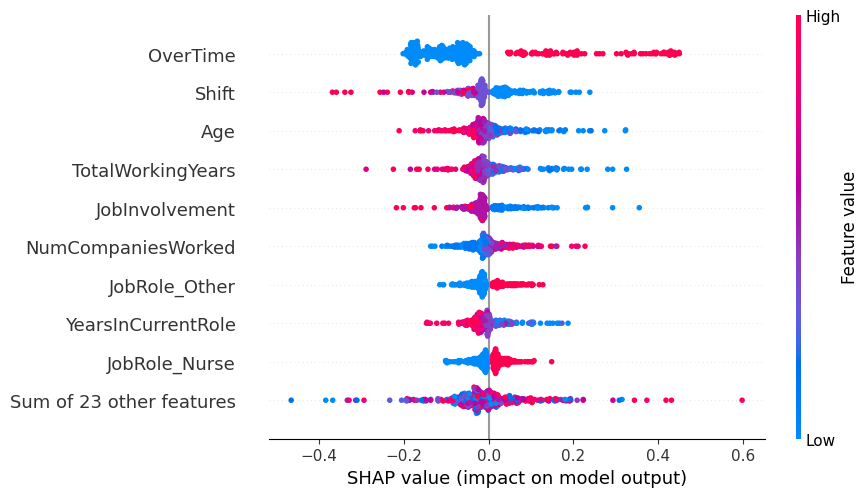

In [71]:
from scipy.special import softmax
import shap
shap.initjs()

shap_values_array = []

# for model in best_models:
# Fits the explainer
explainer = shap.Explainer(model.predict, X_test_processed, feature_names=X_test_df.columns.tolist())
shap_values = explainer(X_test_processed)
shap_values_array.append(shap_values)
shap.plots.beeswarm(shap_values)

In [ ]:
len(shap_values_array[0])

In [ ]:
# X_test_tensor = torch.tensor(X_test.values)

# explainer = shap.DeepExplainer(best_dnn_model, X_test_tensor)
# shap_values = explainer.shap_values(X_test_tensor)
# shap_values_array.append(shap_values)

In [ ]:
def print_feature_importances_shap_values(shap_values, features):
    '''
    Prints the feature importances based on SHAP values in an ordered way
    shap_values -> The SHAP values calculated from a shap.Explainer object
    features -> The name of the features, on the order presented to the explainer
    '''
    # Calculates the feature importance (mean absolute shap value) for each feature
    importances = []
    for i in range(shap_values.values.shape[1]):
        importances.append(np.mean(np.abs(shap_values.values[:, i])))
    # Calculates the normalized version
    importances_norm = softmax(importances)
    # Organize the importances and columns in a dictionary
    feature_importances = {fea: imp for imp, fea in zip(importances, features)}
    feature_importances_norm = {fea: imp for imp, fea in zip(importances_norm, features)}
    # Sorts the dictionary
    feature_importances = {k: v for k, v in sorted(feature_importances.items(), key=lambda item: item[1], reverse = True)}
    feature_importances_norm= {k: v for k, v in sorted(feature_importances_norm.items(), key=lambda item: item[1], reverse = True)}
    # Prints the feature importances
    for k, v in feature_importances.items():
        print(f"{k} -> {v:.4f} (softmax = {feature_importances_norm[k]:.4f})")

In [ ]:
# shap_values_array[1].shape, shap_values_array[2].shape

In [ ]:
print("==== SHAP for Shallow model ====")
print_feature_importances_shap_values(shap_values_array[0], X_test_df.columns)
shap.plots.bar(shap_values_array[0])

In [ ]:
shap_values_array[0].shape

In [ ]:
# reshaped_arr = shap_values_array[0].values.reshape(336, 32)
# reshaped_arr.shape

In [ ]:
# # Create an Explanation object
# explanation = shap.Explanation(
#     values=reshaped_arr, #values is the shap values
#     #base_values=X_test_tensor, #Replace with actual base values, or calculate manually if necessary
#     data=X_test_processed, #Data used to create shap values
#     feature_names=X_test_df.columns
# )

# # Now 'explanation' is a shap.Explanation object, not a numpy array
# print(type(explanation))

In [ ]:
import re
import numpy as np
from scipy.special import softmax

def extract_base_feature_name(lime_feature_string):
    """
    Extracts the base feature name from a LIME feature string (e.g., 'MonthlyRate <= 841.70' -> 'MonthlyRate').
    Handles cases with operators, spaces, and numbers.
    """
    # Find all sequences of word characters that start with an alphabet or underscore
    # This should capture potential feature names like 'OverTime', 'MonthlyRate', 'Department_Maternity'
    matches = re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]*\b', lime_feature_string)

    # Filter out potential numeric parts or keywords that are not feature names
    # For now, let's assume the actual feature name is the first non-numeric looking word.
    for match in matches:
        if not match.replace('_', '').isdigit(): # Ensure it's not purely numeric after removing underscores
            return match
    return lime_feature_string # Fallback: return original string if no suitable word found

def get_lime_top_features_base_names(sorted_lime_teams, N):
    """
    Extracts the top N important feature base names from sorted LIME team counts.
    """
    base_feature_names = []
    seen_features = set()
    for team_feature_string, _ in sorted_lime_teams:
        base_name = extract_base_feature_name(team_feature_string)
        if base_name not in seen_features:
            base_feature_names.append(base_name)
            seen_features.add(base_name)
        if len(base_feature_names) == N:
            break
    return base_feature_names

def get_shap_top_features(shap_values, feature_names, N):
    """
    Extracts the top N important features (by mean absolute SHAP value) from SHAP outputs.
    """
    if not isinstance(shap_values, list) and hasattr(shap_values, 'values'):
        # Handles shap.Explanation object
        abs_shap_values = np.abs(shap_values.values)
    elif isinstance(shap_values, list) and shap_values and hasattr(shap_values[0], 'values'):
        # Handles list of shap.Explanation objects (e.g., for multi-output models, if needed)
        # For simplicity, we'll assume a single Explanation object or use the first if a list
        abs_shap_values = np.abs(shap_values[0].values)
    else:
        raise ValueError("Invalid shap_values object. Expected shap.Explanation or list of shap.Explanation.")

    # Calculate mean absolute SHAP value for each feature
    importances = np.mean(abs_shap_values, axis=0)

    # Create a dictionary of feature names to importances
    feature_importances_dict = {fea: imp for fea, imp in zip(feature_names, importances)}

    # Sort features by importance in descending order
    sorted_shap_features = sorted(feature_importances_dict.items(), key=lambda item: item[1], reverse=True)

    # Return the top N feature names
    return [feature for feature, _ in sorted_shap_features[:N]]

def get_top_n_important_features(lime_sorted_teams, shap_values, shap_feature_names, N):
    """
    Combines top N important features from LIME and SHAP outputs.

    Args:
        lime_sorted_teams (list): List of (feature_string, count) tuples from LIME, sorted by count.
        shap_values (shap.Explanation or list of shap.Explanation): SHAP explanation object(s).
        shap_feature_names (list): List of feature names corresponding to SHAP values.
        N (int): The number of top features to consider from each method.

    Returns:
        list: A list of common top N important features.
    """
    # Get top N features from LIME (base names)
    top_lime_features = get_lime_top_features_base_names(lime_sorted_teams, N)
    print(f"Top {N} LIME features: {top_lime_features}")

    # Get top N features from SHAP
    top_shap_features = get_shap_top_features(shap_values, shap_feature_names, N)
    print(f"Top {N} SHAP features: {top_shap_features}")

    # Find common features
    common_features = list(set(top_lime_features) & set(top_shap_features))
    return common_features

In [81]:
N = 12  # Number of top features to consider

common_features = get_top_n_important_features(sorted_teams, shap_values_array[0], X_test_df.columns.tolist(), N)

print("\nCommon Top Important Features (LIME & SHAP):", common_features)

Top 12 LIME features: ['MonthlyRate', 'DailyRate', 'TotalWorkingYears', 'OverTime', 'Shift', 'NumCompaniesWorked', 'JobRole_Therapist', 'JobInvolvement', 'EducationField_Other', 'YearsInCurrentRole', 'JobLevel', 'JobRole_Administrative']
Top 12 SHAP features: ['OverTime', 'Shift', 'Age', 'TotalWorkingYears', 'JobInvolvement', 'NumCompaniesWorked', 'JobRole_Other', 'YearsInCurrentRole', 'JobRole_Nurse', 'DistanceFromHome', 'EnvironmentSatisfaction', 'JobLevel']

Common Top Important Features (LIME & SHAP): ['JobLevel', 'JobInvolvement', 'TotalWorkingYears', 'YearsInCurrentRole', 'NumCompaniesWorked', 'OverTime', 'Shift']


Common important features from LIME and SHAP are listed below:
1. OverTime
2. Shift
3. JobLevel
4. NumCompaniesWorked
5. JobInvolvement
6. TotalWorkingYears
7. Age
8. DistanceFromHome
9. EnvironmentSatisfaction
10. TrainingTimesLastYear

## Counterfactuals

In [82]:
!pip install dice-ml

In [ ]:
for column in df.columns:
  print(f"Column '{column}': {df[column].nunique()} unique values")

In [ ]:
continuous_features = [col for col in df.columns if df[col].nunique() > 8]

In [ ]:
import dice_ml
# Dataset
data_dice = dice_ml.Data(dataframe=pd.concat([X_train_res_df, pd.Series(y_train_res, name='Attrition')], axis=1),
                         continuous_features=columns_to_normalize,
                         outcome_name='Attrition')

## For best Shallow Model
rf_dice = dice_ml.Model(model=model,
                        # There exist backends for tf, torch, ...
                        backend="sklearn")
explainer = dice_ml.Dice(data_dice,
                         rf_dice,
                         # Random sampling, genetic algorithm, kd-tree,...
                         method="random")

# Generate CF based on the blackbox model
input_datapoint = X_test_df[1:2]
cf = explainer.generate_counterfactuals(input_datapoint,
                                  total_CFs=3,
                                  desired_class="opposite")

# Visualize it
cf.visualize_as_dataframe(show_only_changes=True)

In [86]:
feasible_features_from_all = ['OverTime', 'Shift', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'TrainingTimesLastYear', 'BusinessTravel', 'YearsSinceLastPromotion', 'PercentSalaryHike', 'DailyRate', 'HourlyRate', 'MonthlyRate']
# top: 16 -> common -> ['BusinessTravel', 'DistanceFromHome', 'TotalWorkingYears', 'JobLevel', 'JobInvolvement', 'Shift', 'JobRole_Other', 'OverTime', 'YearsInCurrentRole', 'NumCompaniesWorked']
feasible_features_from_top_16 = ['JobLevel', 'JobInvolvement', 'Shift', 'OverTime', 'BusinessTravel']
# top: 14 -> common -> ['BusinessTravel', 'DistanceFromHome', 'TotalWorkingYears', 'JobLevel', 'JobInvolvement', 'Shift', 'OverTime', 'YearsInCurrentRole', 'NumCompaniesWorked']
feasible_features_from_top_14 = ['JobLevel', 'JobInvolvement', 'Shift', 'OverTime', 'BusinessTravel']
# top: 12 -> common -> ['DistanceFromHome', 'TotalWorkingYears', 'JobInvolvement', 'Shift', 'OverTime', 'YearsInCurrentRole', 'NumCompaniesWorked']
feasible_features_from_top_12 = ['JobInvolvement', 'Shift', 'OverTime']
# top: 10 -> common -> ['TotalWorkingYears', 'JobInvolvement', 'Shift', 'OverTime', 'NumCompaniesWorked']
feasible_features_from_top_10 = ['JobInvolvement', 'Shift']
# top: 8  -> common -> ['TotalWorkingYears', 'JobInvolvement', 'Shift', 'OverTime', 'NumCompaniesWorked']
feasible_features_from_top_8 = ['JobInvolvement', 'Shift']

In [87]:
# Create feasible (conditional) Counterfactuals
features_to_vary=['JobLevel',
                  'JobInvolvement',
                  'Shift',
                  'OverTime',
                  'BusinessTravel']
#permitted_range={'BusinessTravel_Travel_Frequently':[1,5],
#                'TrainingTimesLastYear':[0, 30]}
# Now generating explanations using the new feature weights
cf = explainer.generate_counterfactuals(input_datapoint,
                                  total_CFs=3,
                                  desired_class="opposite",
                                  #permitted_range=permitted_range,
                                  features_to_vary=features_to_vary)
# Visualize it
cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  6.20it/s]

Query instance (original outcome : 1.0)


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,EducationField_Life Sciences,EducationField_Marketing,EducationField_Other,JobRole_Administrative,JobRole_Nurse,JobRole_Other,JobRole_Therapist,MaritalStatus_Married,MaritalStatus_Single,Attrition
0,-0.476893,1.0,0.377327,0.368884,0.121595,4.0,1.478246,2.0,-0.780959,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0



Diverse Counterfactual set (new outcome: 0.0)


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,EducationField_Life Sciences,EducationField_Marketing,EducationField_Other,JobRole_Administrative,JobRole_Nurse,JobRole_Other,JobRole_Therapist,MaritalStatus_Married,MaritalStatus_Single,Attrition
0,-,-,-,-,-,-,-,-,3.0514765,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,4.0,-,-,...,-,-,-,-,-,-,-,-,-,0.0
2,-,-,-,-,-,-,-,-,2.9148446,-,...,-,-,-,-,-,-,-,-,-,0.0


## Lime-SHAP-Counterfactual XAI

100%|██████████| 1/1 [00:00<00:00,  3.20it/s]


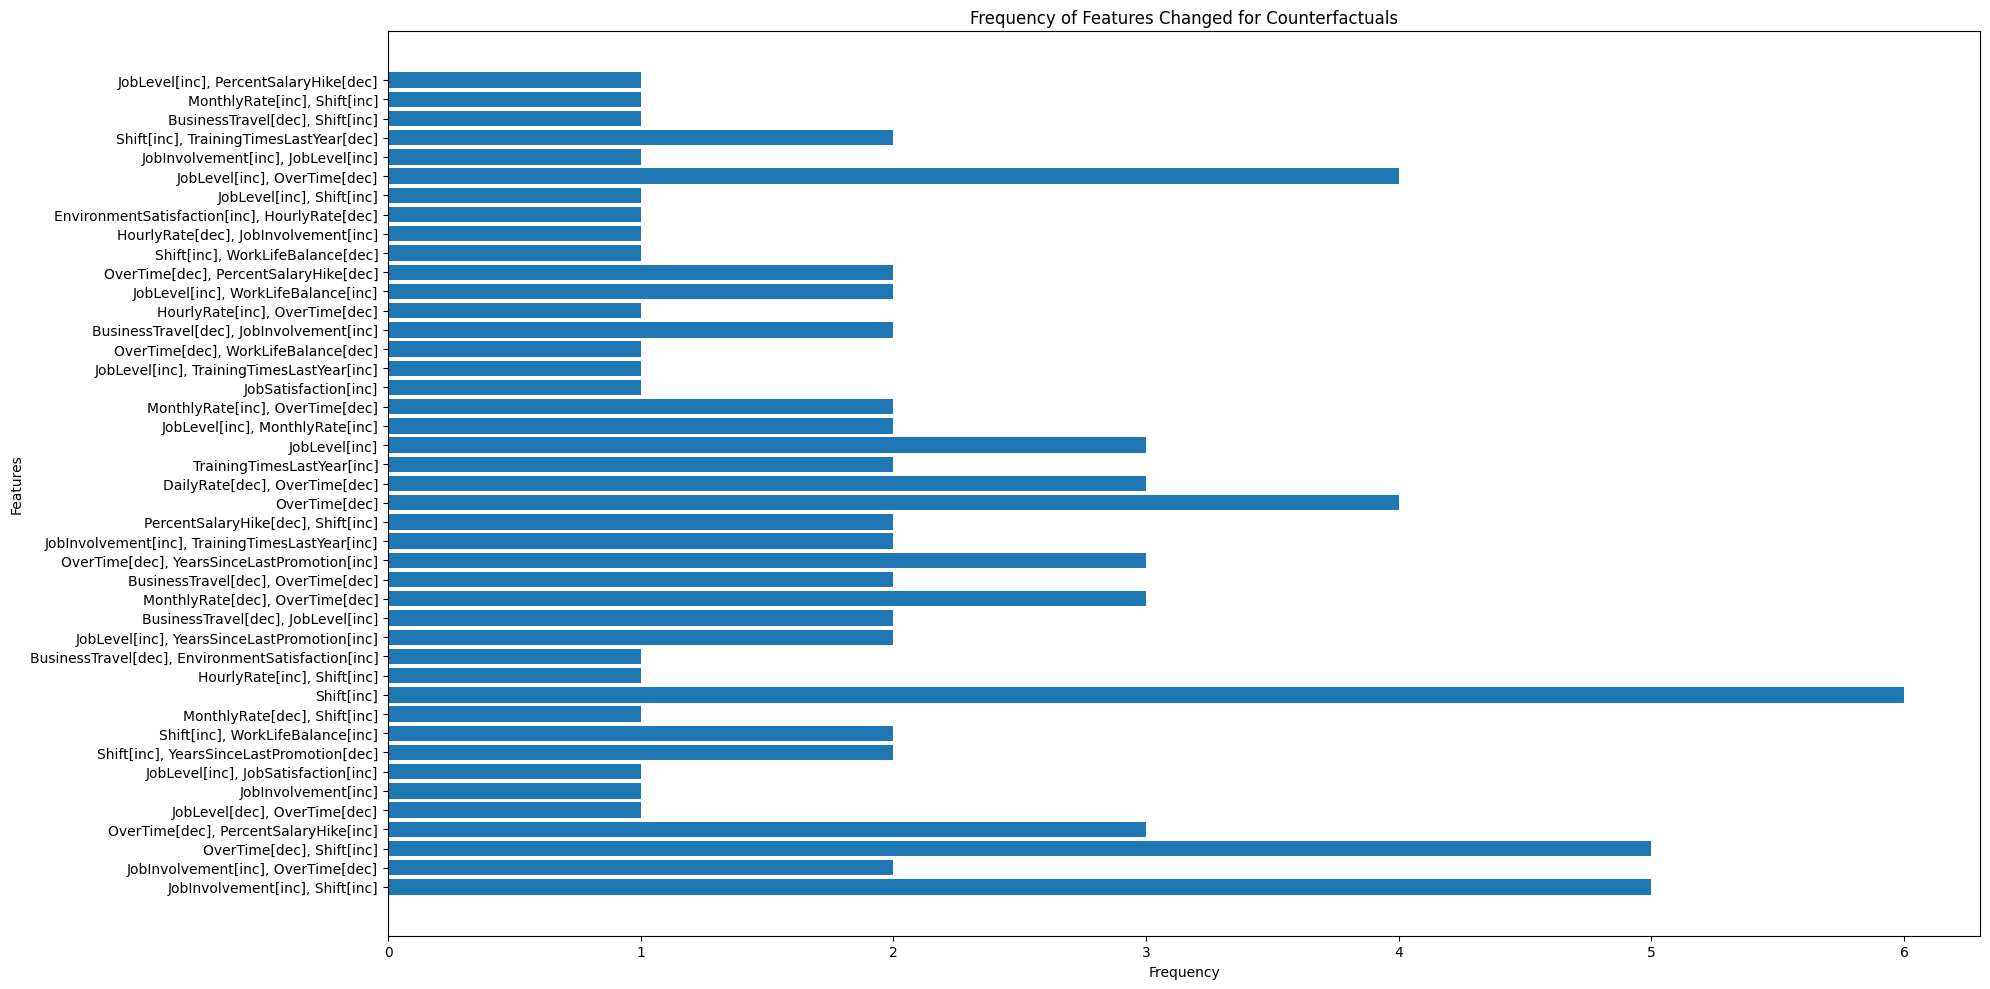

In [88]:
global_changable_cols = []
y_test_series = pd.Series(y_test)
y_pred_series = pd.Series(y_pred)

for j in range(len(X_test_df)):
  if y_test_series.iloc[j] == 0.0 or y_test_series.iloc[j] != y_pred_series.iloc[j]: # if not attrition or if it is not predicted correctly, we do not need to consider
    continue
  input_datapoint = X_test_df.iloc[j:j+1]
  # Try to make features_to_vary less restrictive to find counterfactuals
  try:
    cf = explainer.generate_counterfactuals(input_datapoint,
                                          total_CFs=3,
                                          desired_class="opposite",
                                          features_to_vary = feasible_features_from_all) # Changed features_to_vary to "all" to allow all features to vary
  except:
    continue
  if cf.cf_examples_list and cf.cf_examples_list[0].final_cfs_df is not None and not cf.cf_examples_list[0].final_cfs_df.empty:
    cf_df = cf.cf_examples_list[0].final_cfs_df
    if 'Attrition' in cf_df.columns:
      cf_df.drop('Attrition', axis=1, inplace=True)
    cf_df_numpy = cf_df.to_numpy()

    for i in range(len(cf_df)):
      row = cf_df.iloc[i]
      changable_cols = []
      for col in row.index:
        if(col in input_datapoint.columns and row[col] != input_datapoint[col].values[0]):
          additional = ""
          if(row[col] > input_datapoint[col].values[0]):
            additional = "[inc]"
          else:
            additional = "[dec]"
          changable_cols.append(col+additional)
      if changable_cols: # Only append if there are actual changes
        global_changable_cols.append(changable_cols)
  else:
    print(f"No counterfactuals found for instance {j}")


# Flatten the list of lists
all_teams = [team for team in global_changable_cols]

all_teams_as_str = [', '.join(team) for team in all_teams]

# Count the frequency of each team
team_counts = Counter(team for team in all_teams_as_str)

# Extract the team names and counts for plotting
teams = list(team_counts.keys())
counts = list(team_counts.values())

# Create the bar plot
plt.figure(figsize=(20, 10))
plt.barh(teams, counts) # Use barh for horizontal bar plot
plt.ylabel("Features") # Y-axis now represents features
plt.xlabel("Frequency") # X-axis now represents frequency
plt.title("Frequency of Features Changed for Counterfactuals")
# plt.xticks(rotation=90) # No need to rotate x-axis labels for horizontal bar plot
plt.tight_layout() # Adjust layout
plt.show()

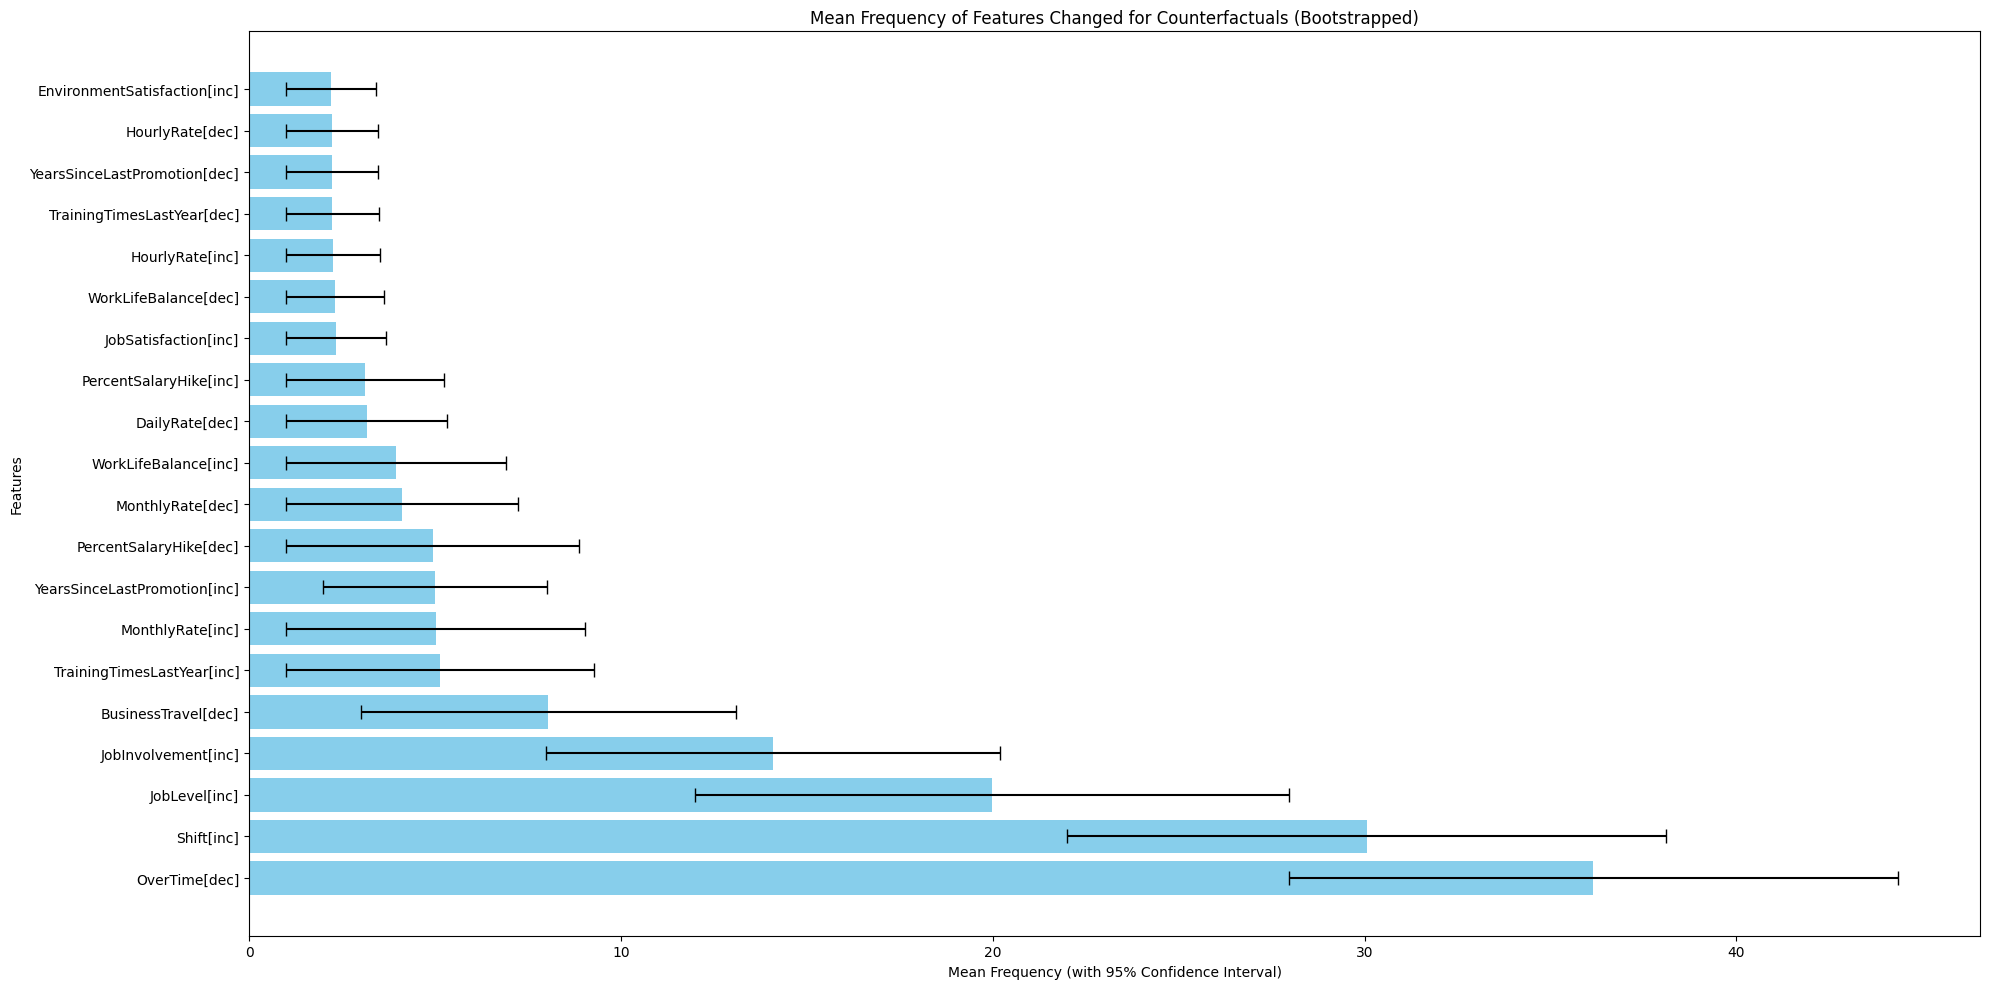

In [90]:
# Flatten the list of lists (each inner list represents features changed for one set of counterfactuals)
all_teams_flat_lists = global_changable_cols

# Number of bootstrap samples
n_bootstraps = 1000
# Confidence level for intervals
confidence_level = 0.95

bootstrapped_counts = {} # To store counts for each feature across bootstrap samples

for _ in range(n_bootstraps):
    # Resample the list of lists with replacement
    resampled_lists_indices = np.random.choice(len(all_teams_flat_lists), size=len(all_teams_flat_lists), replace=True)
    resampled_lists = [all_teams_flat_lists[i] for i in resampled_lists_indices]

    # Flatten the resampled lists into a single list of features
    current_bootstrap_features = [feature for sublist in resampled_lists for feature in sublist]

    # Count frequencies for the current bootstrap sample
    current_counts = Counter(current_bootstrap_features)

    # Store these counts
    for feature, count in current_counts.items():
        if feature not in bootstrapped_counts:
            bootstrapped_counts[feature] = []
        bootstrapped_counts[feature].append(count)

# Calculate mean and confidence intervals for each feature
feature_stats = []
for feature, counts_list in bootstrapped_counts.items():
    if len(counts_list) >= 2: # Ensure enough data to calculate CI
        mean_count = np.mean(counts_list)
        # Calculate the lower and upper percentile for the confidence interval
        lower_bound = np.percentile(counts_list, (1 - confidence_level) / 2 * 100)
        upper_bound = np.percentile(counts_list, (1 + confidence_level) / 2 * 100)

        feature_stats.append({
            'Feature': feature,
            'Mean_Frequency': mean_count,
            'Lower_CI': lower_bound,
            'Upper_CI': upper_bound
        })

# Convert to DataFrame and sort by mean frequency
feature_stats_df = pd.DataFrame(feature_stats).sort_values(by='Mean_Frequency', ascending=False)

# Filter to include only features with mean frequency >= 2
feature_stats_df = feature_stats_df[feature_stats_df['Mean_Frequency'] >= 2]

# Prepare data for plotting
teams = feature_stats_df['Feature'].tolist()
mean_counts = feature_stats_df['Mean_Frequency'].tolist()
lower_ci = feature_stats_df['Lower_CI'].tolist()
upper_ci = feature_stats_df['Upper_CI'].tolist()

# Calculate error bars
error_bars = [mean_counts[i] - lower_ci[i] for i in range(len(mean_counts))]

# Create the bar plot with confidence intervals
plt.figure(figsize=(20, 10))
plt.barh(teams, mean_counts, xerr=error_bars, capsize=5, color='skyblue')
plt.ylabel("Features")
plt.xlabel(f"Mean Frequency (with {int(confidence_level * 100)}% Confidence Interval)")
plt.title("Mean Frequency of Features Changed for Counterfactuals (Bootstrapped)")
plt.tight_layout()
plt.show()